# Functional connectivity analysis of EEG signals

*medusa-kernel 2.0*

While *local activation* metrics describe each channel on its own,
**functional connectivity** quantifies the **relationships between
channels** — how different scalp regions interact over time. Each metric
returns an **adjacency matrix** whose entries are the connectivity between
every pair of channels.

`medusa.signal.metrics.connectivity` provides two families:

- **Phase-based** — synchrony between the *instantaneous phases* of two
  signals: `plv`, `pli`, `wpli`.
- **Amplitude-based** — correlation between their *amplitude envelopes*:
  `aec`, `iac`.

You will learn how to:

- synthesise an EEG with **band-specific coupled networks** using
  `medusa.signal.generators`,
- compute phase- and amplitude-based connectivity,
- visualise adjacency matrices and scalp connectivity maps with
  `medusa.plots`.

All data is **synthetic**, so the notebook runs anywhere with no download.

## Imports

<div class="alert alert-block alert-danger">
Important: execute the following cell <b>only</b> if you're using Google Colab!
</div>

In [1]:
!pip install medusa-kernel

Import the modules used in this notebook.

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import medusa_style
import medusa.plots as mp
from medusa.core.data import ChannelSet
from medusa.signal.generators import EEGSignalGenerator
from medusa.signal.frequency_filtering import FIRFilter
from medusa.signal.spatial_filtering import car
from medusa.signal.segmentation import segment_signal
from medusa.signal.metrics.connectivity import plv, pli, wpli, aec

medusa_style.apply()
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)
print('> All required packages were successfully imported')

> All required packages were successfully imported


## Synthesise EEG with coupled networks

Connectivity is only meaningful if the data actually contains coupling, so
we plant two **phase-coupled networks** on top of an independent `1/f`
background:

- a **frontal theta network** (6 Hz) over `F3, Fz, F4`,
- a **posterior alpha network** (10 Hz) over `P3, Pz, P4, O1, O2`.

Each network shares one oscillator (so its members are phase-locked), with
a small per-channel phase offset and strong background noise so the
phase-locking is high but realistic. Channels outside a network — and
members of a *different* band's network — stay uncoupled, which lets us
check that each metric recovers the right structure in the right band.

In [3]:
fs = 250.0
duration = 120.0
labels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
          'T7', 'C3', 'Cz', 'C4', 'T8',
          'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
n_cha = len(labels)

# Independent 1/f background per channel (no shared oscillations)
bg = EEGSignalGenerator(fs=fs, oscillations=[], background_amplitude=18.0,
                        seed=42)
signal = bg.get_chunk(duration, n_cha)
t = np.arange(signal.shape[0]) / fs

def add_network(members, freq, amp, seed):
    """Inject a shared oscillator (phase-locked) into a set of channels."""
    rng = np.random.default_rng(seed)
    base_phase = rng.uniform(0, 2 * np.pi)
    for ch in members:
        i = labels.index(ch)
        phase = base_phase + rng.normal(0, 0.25)   # small per-channel offset
        signal[:, i] += amp * np.sin(2 * np.pi * freq * t + phase)

add_network(['F3', 'Fz', 'F4'], freq=6.0, amp=12.0, seed=1)            # theta
add_network(['P3', 'Pz', 'P4', 'O1', 'O2'], freq=10.0, amp=12.0, seed=2)  # alpha

channel_set = ChannelSet().add_unipolar_eeg_channels(labels)
print(f'> Signal shape: {signal.shape}')
print('> Frontal theta network : F3, Fz, F4')
print('> Posterior alpha network: P3, Pz, P4, O1, O2')

> Signal shape: (30000, 19)
> Frontal theta network : F3, Fz, F4
> Posterior alpha network: P3, Pz, P4, O1, O2


## Preprocessing

For connectivity we:

- re-reference with a **Common Average Reference** (CAR), which attenuates
  shared artefacts that would inflate connectivity,
- **band-pass filter** into the bands of interest (theta 4-8 Hz, alpha
  8-13 Hz, beta 13-30 Hz),
- split each band into 5 s **epochs**.

The connectivity functions take band-filtered, epoched data of shape
`(n_epochs, n_samples, n_channels)` and apply the Hilbert transform
internally to obtain the analytic signal.

In [4]:
signal_car = car(signal)

bands = {'Theta': (4, 8), 'Alpha': (8, 13), 'Beta': (13, 30)}
epochs_by_band = {}
for name, (lo, hi) in bands.items():
    fir = FIRFilter(order=500, cutoff=(lo, hi), btype='bandpass')
    filt = fir.fit_transform(signal_car, fs)
    epochs_by_band[name] = segment_signal(filt, segment_length=int(5 * fs))

print('> Epochs per band:',
      {k: v.shape for k, v in epochs_by_band.items()})

> Epochs per band: {'Theta': (24, 1250, 19), 'Alpha': (24, 1250, 19), 'Beta': (24, 1250, 19)}


## Phase-based connectivity

We compute three phase-based metrics for every band and average the
per-epoch adjacency matrices:

- **PLV** (Phase-Locking Value) — raw phase synchrony.
- **PLI** (Phase Lag Index) — ignores zero-lag coupling, so it is robust to
  volume conduction.
- **wPLI** (weighted PLI) — a less noise-sensitive refinement of PLI.

Let's first look at the **alpha-band** adjacency matrices. The posterior
network (P3, Pz, P4, O1, O2) should form a bright block, and little else.

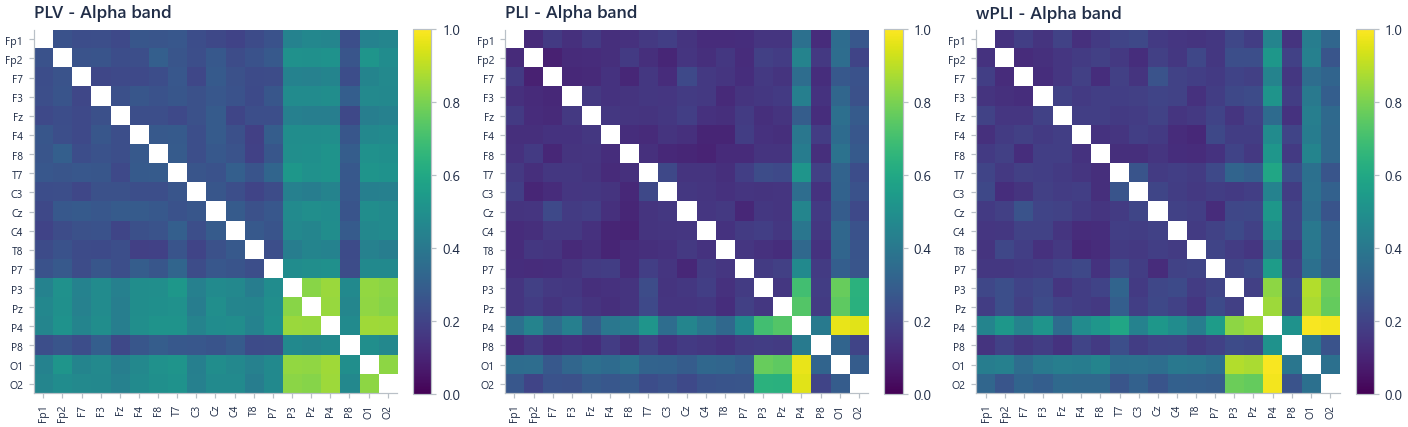

In [5]:
def connectivity_matrix(metric, epochs):
    """Average a per-epoch connectivity metric over epochs."""
    conn = np.nanmean(metric(epochs), axis=0)
    np.fill_diagonal(conn, np.nan)
    return conn

measures = {'PLV': plv, 'PLI': pli, 'wPLI': wpli}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, metric) in zip(axes, measures.items()):
    conn = connectivity_matrix(metric, epochs_by_band['Alpha'])
    im = ax.imshow(conn, cmap=medusa_style.mpl.sequential_cmap(), vmin=0, vmax=1)
    ax.grid(False)
    ax.set_title(f'{name} - Alpha band')
    ax.set_xticks(range(n_cha)); ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticks(range(n_cha)); ax.set_yticklabels(labels, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Connectivity on the scalp

Adjacency matrices are exact but hard to read spatially. `plot_connectivity`
draws the strongest edges of an adjacency matrix directly on the scalp
(keeping edges above the `threshold` percentile). Here is every
measure × band combination — note how each network appears **only** in its
own band.

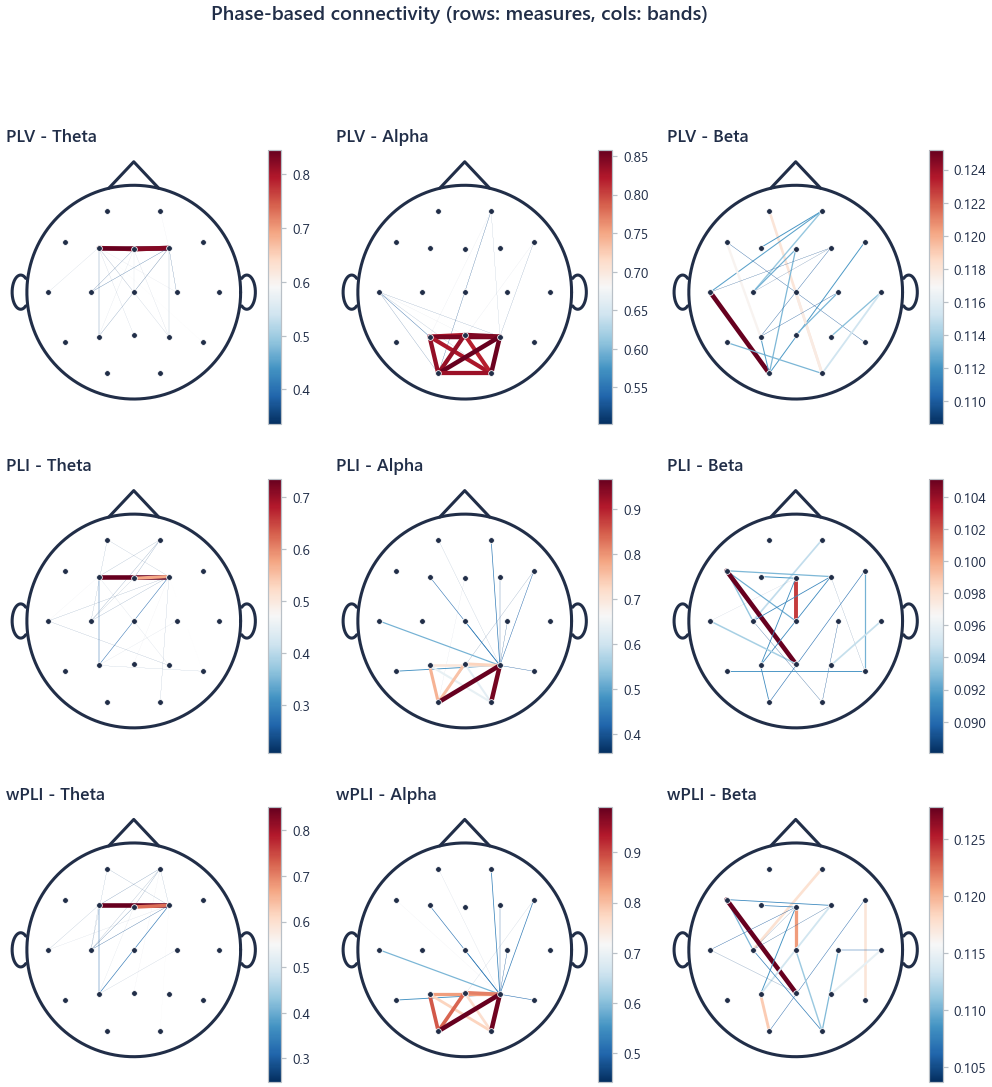

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for r, (mname, metric) in enumerate(measures.items()):
    for c, band_name in enumerate(bands):
        ax = axes[r, c]
        conn = connectivity_matrix(metric, epochs_by_band[band_name])
        mp.plot_connectivity(np.nan_to_num(conn), channel_set, ax,
                             threshold=88, colorbar=True)
        ax.set_title(f'{mname} - {band_name}')
fig.suptitle('Phase-based connectivity (rows: measures, cols: bands)', y=1.0)
mp.save_figure(fig, RESULTS / 'phase_connectivity_grid.png')
plt.show()

## Amplitude-based connectivity

**Amplitude Envelope Correlation** (AEC) correlates the amplitude envelopes
of two band-limited signals. With `ort=True` the signals are
**orthogonalised** first, which removes the zero-lag component responsible
for spurious volume-conduction connectivity. `medusa` also offers `iac`
(Instantaneous Amplitude Correlation).

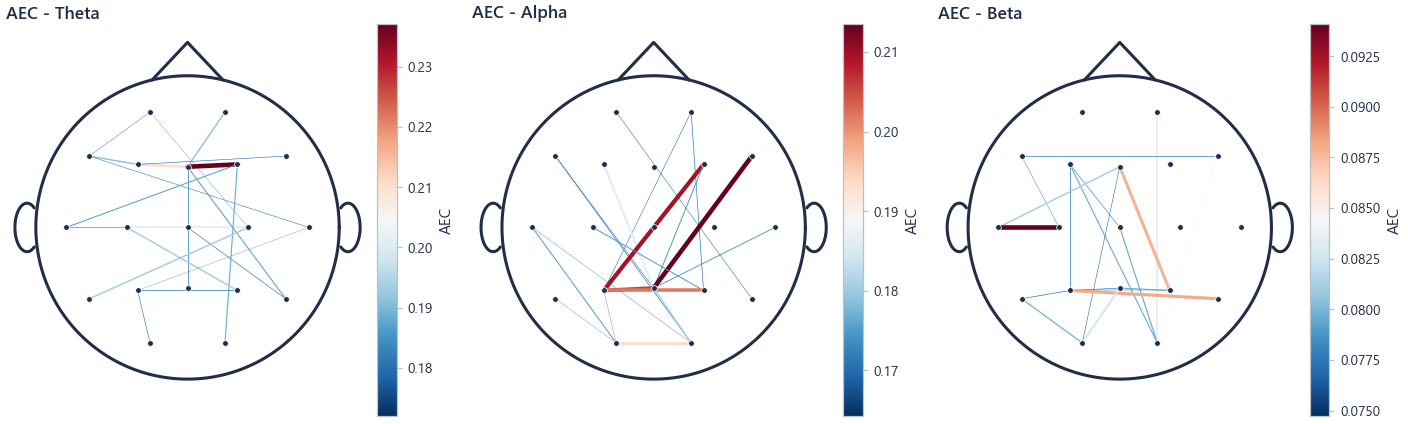

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, band_name in zip(axes, bands):
    conn = np.nanmean(aec(epochs_by_band[band_name], ort=True), axis=0)
    np.fill_diagonal(conn, np.nan)
    mp.plot_connectivity(np.nan_to_num(conn), channel_set, ax,
                         threshold=88, colorbar=True, cbar_label='AEC')
    ax.set_title(f'AEC - {band_name}')
plt.tight_layout()
plt.show()

## Summary and next steps

In this tutorial you:

- synthesised an EEG with band-specific **coupled networks** using
  `medusa.signal.generators`,
- preprocessed it (CAR, band-pass, epoching),
- computed **phase-based** (`plv`, `pli`, `wpli`) and **amplitude-based**
  (`aec`) connectivity,
- visualised adjacency matrices and scalp connectivity maps with
  `medusa.plots`, confirming each network shows up only in its own band.

Ways to build on this:

- compare connectivity between experimental conditions,
- summarise networks with the graph-theory metrics in `medusa.graph`
  (degree, modularity, efficiency, ...),
- explore time-resolved (dynamic) connectivity with sliding windows.

See you in the next MEDUSA tutorial!

## References

1. Lachaux, J.-P., Rodriguez, E., Martinerie, J., & Varela, F. J. (1999).
   *Measuring phase synchrony in brain signals.* Hum. Brain Mapp., 8(4),
   194-208.
2. Stam, C. J., Nolte, G., & Daffertshofer, A. (2007). *Phase lag index.*
   Hum. Brain Mapp., 28(11), 1178-1193.
3. Vinck, M., et al. (2011). *An improved index of phase-synchronization
   (wPLI).* NeuroImage, 55(4), 1548-1565.
4. Hipp, J. F., et al. (2012). *Large-scale cortical correlation structure
   of spontaneous oscillatory activity.* Nat. Neurosci., 15(6), 884-890.